## Objective: Evaluate if a personalized diet reduces average fasting glucose more than a standard plan.

Hypothesis:

H0: There is no difference in fasting glucose reduction between personalized and standard nutrition plans.

H1: Personalized nutrition leads to greater reduction in fasting glucose.

In [26]:
import numpy as np
import pandas as pd


# loading data from a CSV file
df=pd.read_csv('diabetic_nutrition_study_data.csv')

# Show sample
print(df.head())


  Patient_ID         Group  Glucose_Before  Glucose_After  Glucose_Change
0      P0001  Personalized           167.5          145.7            21.8
1      P0002  Personalized           157.9          135.1            22.8
2      P0003  Personalized           169.7          144.3            25.4
3      P0004  Personalized           182.8          157.6            25.2
4      P0005  Personalized           156.5          143.4            13.1


## Data Cleaning

Missing Values:
 Patient_ID        0
Group             0
Glucose_Before    0
Glucose_After     0
Glucose_Change    0
dtype: int64

Outliers in Glucose_Before: 3
Outliers in Glucose_After: 2


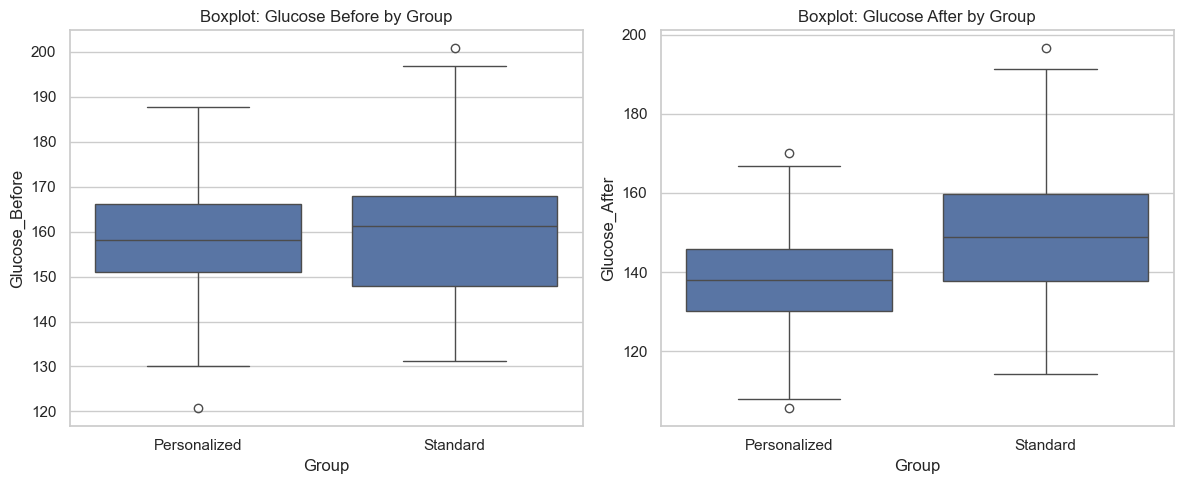


Group Distribution:
 Group
Personalized    100
Standard        100
Name: count, dtype: int64

Summary Statistics by Group:
              Glucose_Before                Glucose_After                 \
                       mean  median    std          mean  median    std   
Group                                                                     
Personalized         158.44  158.10  13.63        138.11  137.90  13.67   
Standard             160.34  161.25  14.30        149.58  148.75  15.69   

             Glucose_Change               
                       mean median   std  
Group                                     
Personalized          20.33   20.5  5.42  
Standard              10.75   10.4  6.19  


In [27]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset (if already saved)
# df = pd.read_csv('diabetic_nutrition_study_data.csv')

# ----- Step 3.1: Handle Missing Values -----
print("Missing Values:\n", df.isnull().sum())

# Drop rows with missing values (if any)
df_clean = df.dropna()

# Alternatively, you could impute:
# df['Glucose_Before'] = df['Glucose_Before'].fillna(df['Glucose_Before'].mean())

# ----- Step 3.2: Check for Outliers -----
def detect_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return series[(series < lower) | (series > upper)]

outliers_before = detect_outliers_iqr(df_clean['Glucose_Before'])
outliers_after = detect_outliers_iqr(df_clean['Glucose_After'])

print(f"\nOutliers in Glucose_Before: {len(outliers_before)}")
print(f"Outliers in Glucose_After: {len(outliers_after)}")

# Visualize outliers using boxplots
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(x='Group', y='Glucose_Before', data=df_clean)
plt.title('Boxplot: Glucose Before by Group')

plt.subplot(1, 2, 2)
sns.boxplot(x='Group', y='Glucose_After', data=df_clean)
plt.title('Boxplot: Glucose After by Group')
plt.tight_layout()
plt.show()

# ----- Step 3.3: Check Group Balance -----
group_counts = df_clean['Group'].value_counts()
print("\nGroup Distribution:\n", group_counts)

# ----- Step 3.4: Summary Statistics -----
summary_stats = df_clean.groupby('Group').agg({
    'Glucose_Before': ['mean', 'median', 'std'],
    'Glucose_After': ['mean', 'median', 'std'],
    'Glucose_Change': ['mean', 'median', 'std']
}).round(2)

print("\nSummary Statistics by Group:\n", summary_stats)


## Normality Testing

📌 Shapiro-Wilk Test Results (p > 0.05 means 'data is normal'):


🔹 Group: Personalized
Glucose_Before: W = 0.9899, p = 0.6557 -> Normal
Glucose_After: W = 0.9904, p = 0.6990 -> Normal
Glucose_Change: W = 0.9858, p = 0.3602 -> Normal

🔹 Group: Standard
Glucose_Before: W = 0.9776, p = 0.0857 -> Normal
Glucose_After: W = 0.9881, p = 0.5126 -> Normal
Glucose_Change: W = 0.9898, p = 0.6513 -> Normal


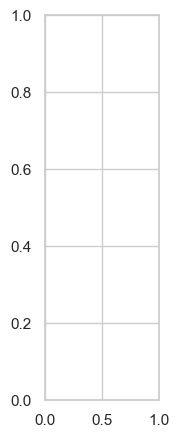

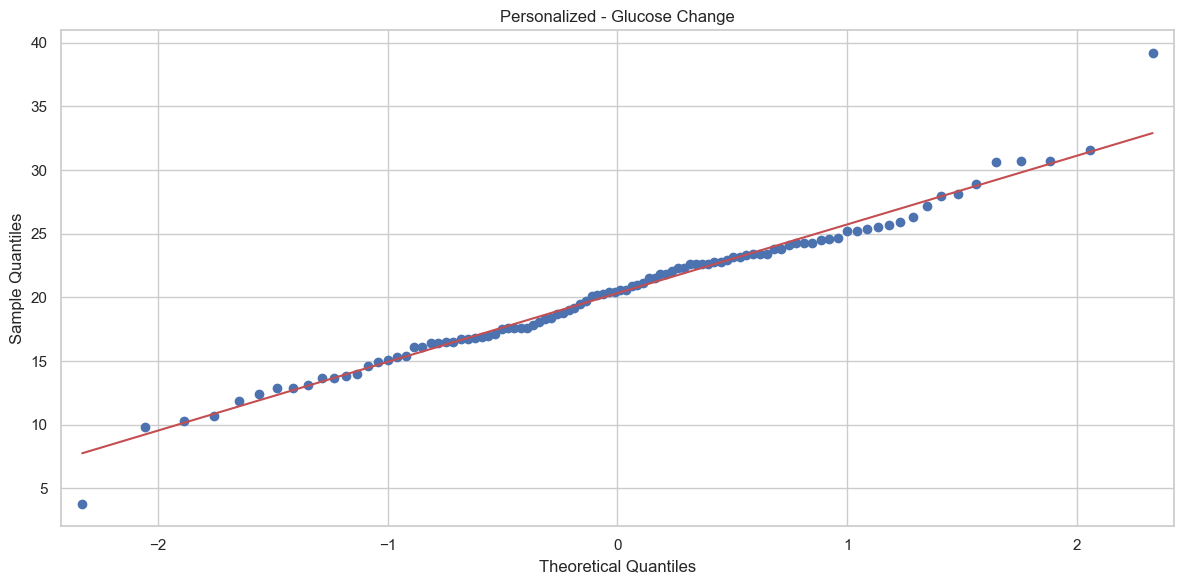

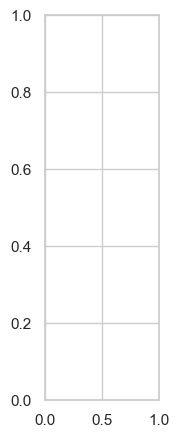

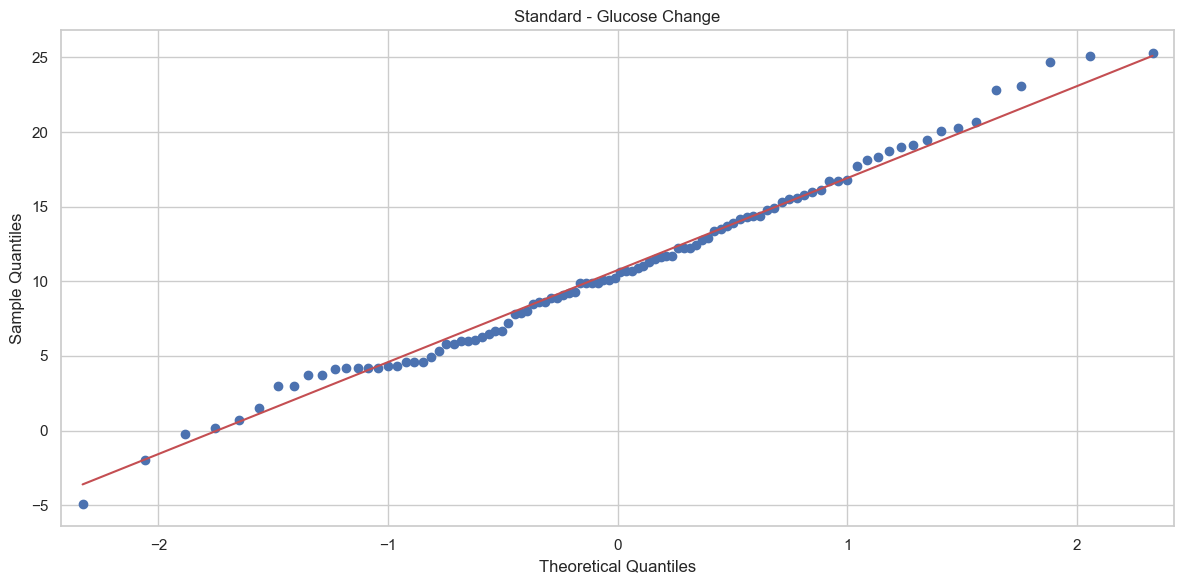

In [28]:
from scipy import stats
import statsmodels.api as sm
import matplotlib.pyplot as plt

# --- Step 4.1: Shapiro-Wilk Test for Normality ---

print("📌 Shapiro-Wilk Test Results (p > 0.05 means 'data is normal'):\n")

# Function to apply Shapiro test
def shapiro_test(data, label):
    stat, p = stats.shapiro(data)
    print(f"{label}: W = {stat:.4f}, p = {p:.4f} -> {'Normal' if p > 0.05 else 'Not Normal'}")

# By Group
for group in df_clean['Group'].unique():
    grp_data = df_clean[df_clean['Group'] == group]

    print(f"\n🔹 Group: {group}")
    shapiro_test(grp_data['Glucose_Before'], 'Glucose_Before')
    shapiro_test(grp_data['Glucose_After'], 'Glucose_After')
    shapiro_test(grp_data['Glucose_Change'], 'Glucose_Change')

# --- Step 4.2: QQ Plots ---

def qq_plot(data, title):
    sm.qqplot(data, line='s')
    plt.title(title)
    plt.grid(True)

# Plot QQ plots for each variable in each group
for group in df_clean['Group'].unique():
    grp_data = df_clean[df_clean['Group'] == group]

    plt.figure(figsize=(5, 5))
    

    plt.subplot(1, 3, 3)
    qq_plot(grp_data['Glucose_Change'], f'{group} - Glucose Change')

    plt.tight_layout()
    plt.show()


## Hypothesis test for within groups

In [29]:
from scipy.stats import ttest_rel

# Function to perform paired t-test
def paired_t_test(group_df, group_name): 
    before = group_df['Glucose_Before']
    after = group_df['Glucose_After']
    
    stat, p_value = ttest_rel(before, after)
    
    print(f"🔹 Group: {group_name}")
    print(f"Paired t-test statistic = {stat:.4f}, p-value = {p_value:.4f}")
    if p_value < 0.05:
        print("✅ Statistically significant reduction in glucose levels.\n")
    else:
        print("❌ No statistically significant reduction in glucose levels.\n")

# Run the test for each group
for group in df_clean['Group'].unique():
    group_data = df_clean[df_clean['Group'] == group]
    paired_t_test(group_data, group)


🔹 Group: Personalized
Paired t-test statistic = 37.5020, p-value = 0.0000
✅ Statistically significant reduction in glucose levels.

🔹 Group: Standard
Paired t-test statistic = 17.3589, p-value = 0.0000
✅ Statistically significant reduction in glucose levels.



# Hypothsis test for between groups

In [30]:
from scipy.stats import ttest_ind

# Separate the change values
personalized_change = df_clean[df_clean['Group'] == 'Personalized']['Glucose_Change']
standard_change = df_clean[df_clean['Group'] == 'Standard']['Glucose_Change']

# Perform Independent (Unpaired) t-test
stat, p_value = ttest_ind(personalized_change, standard_change, equal_var=False)  # Welch's t-test

# Summary statistics
mean_diff = personalized_change.mean() - standard_change.mean()

print("🔍 Independent t-test: Personalized vs Standard Diet Plan")
print(f"Mean Glucose Reduction (Personalized): {personalized_change.mean():.2f} mg/dL")
print(f"Mean Glucose Reduction (Standard): {standard_change.mean():.2f} mg/dL")
print(f"Difference in Means: {mean_diff:.2f} mg/dL")
print(f"T-statistic: {stat:.4f}, P-value: {p_value:.4f}")

if p_value < 0.05:
    print("✅ Statistically significant difference in glucose reduction between groups.")
else:
    print("❌ No statistically significant difference in glucose reduction between groups.")


🔍 Independent t-test: Personalized vs Standard Diet Plan
Mean Glucose Reduction (Personalized): 20.33 mg/dL
Mean Glucose Reduction (Standard): 10.75 mg/dL
Difference in Means: 9.58 mg/dL
T-statistic: 11.6418, P-value: 0.0000
✅ Statistically significant difference in glucose reduction between groups.


## Effect size

In [31]:
# Extract data
group1 = df_clean[df_clean['Group'] == 'Personalized']['Glucose_Change']
group2 = df_clean[df_clean['Group'] == 'Standard']['Glucose_Change']

# Sample sizes
n1, n2 = len(group1), len(group2)

# Means and standard deviations
mean1, mean2 = group1.mean(), group2.mean()
std1, std2 = group1.std(), group2.std()

# Pooled standard deviation
pooled_std = np.sqrt(((n1 - 1)*std1**2 + (n2 - 1)*std2**2) / (n1 + n2 - 2))

# Cohen's d
cohen_d = (mean1 - mean2) / pooled_std

# Interpretation thresholds
effect_strength = (
    "Small" if abs(cohen_d) < 0.2 else
    "Medium" if abs(cohen_d) < 0.8 else
    "Large"
)

# Output
print("📏 Cohen's d - Effect Size:")
print(f"Cohen's d = {cohen_d:.4f} → {effect_strength} effect")
print(f"Mean Reduction (Personalized): {mean1:.2f}")
print(f"Mean Reduction (Standard): {mean2:.2f}")
print(f"Pooled SD = {pooled_std:.2f}")


📏 Cohen's d - Effect Size:
Cohen's d = 1.6464 → Large effect
Mean Reduction (Personalized): 20.33
Mean Reduction (Standard): 10.75
Pooled SD = 5.82


## Confidence Interval

In [33]:
import numpy as np
from scipy import stats

# Extract glucose change data
group1 = df_clean[df_clean['Group'] == 'Personalized']['Glucose_Change']
group2 = df_clean[df_clean['Group'] == 'Standard']['Glucose_Change']

# --- Function to compute CI for one group ---
def confidence_interval(data, confidence=0.95):
    n = len(data)
    mean = np.mean(data)
    se = stats.sem(data)  # Standard error
    margin = se * stats.t.ppf((1 + confidence) / 2, n - 1)
    return mean, mean - margin, mean + margin

# CI for each group
mean1, lower1, upper1 = confidence_interval(group1)
mean2, lower2, upper2 = confidence_interval(group2)

# --- CI for difference in means (Welch’s method) ---
mean_diff = mean1 - mean2
se_diff = np.sqrt(group1.var(ddof=1)/len(group1) + group2.var(ddof=1)/len(group2))

# Degrees of freedom using Welch–Satterthwaite equation
df_num = (group1.var(ddof=1)/len(group1) + group2.var(ddof=1)/len(group2))**2
df_denom = ((group1.var(ddof=1)/len(group1))**2 / (len(group1)-1)) + \
           ((group2.var(ddof=1)/len(group2))**2 / (len(group2)-1))
df = df_num / df_denom

# Margin of error for difference
margin_diff = se_diff * stats.t.ppf((1 + 0.95) / 2, df)
lower_diff = mean_diff - margin_diff
upper_diff = mean_diff + margin_diff

# --- Results ---
print("📌 95% Confidence Intervals:\n")

print(f"✅ Personalized Group Mean Reduction: {mean1:.2f} mg/dL")
print(f"   95% CI: [{lower1:.2f}, {upper1:.2f}]")

print(f"\n✅ Standard Group Mean Reduction:    {mean2:.2f} mg/dL")
print(f"   95% CI: [{lower2:.2f}, {upper2:.2f}]")

print(f"\n🔄 Difference in Mean Reduction (Personalized - Standard): {mean_diff:.2f} mg/dL")
print(f"   95% CI: [{lower_diff:.2f}, {upper_diff:.2f}]")


📌 95% Confidence Intervals:

✅ Personalized Group Mean Reduction: 20.33 mg/dL
   95% CI: [19.26, 21.41]

✅ Standard Group Mean Reduction:    10.75 mg/dL
   95% CI: [9.52, 11.98]

🔄 Difference in Mean Reduction (Personalized - Standard): 9.58 mg/dL
   95% CI: [7.96, 11.21]


## Data Visualization

C:\Users\jshre\AppData\Local\Temp\ipykernel_19384\4103126020.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Group', y='Glucose_Before', data=df_clean, palette='pastel')
C:\Users\jshre\AppData\Local\Temp\ipykernel_19384\4103126020.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Group', y='Glucose_After', data=df_clean, palette='pastel')


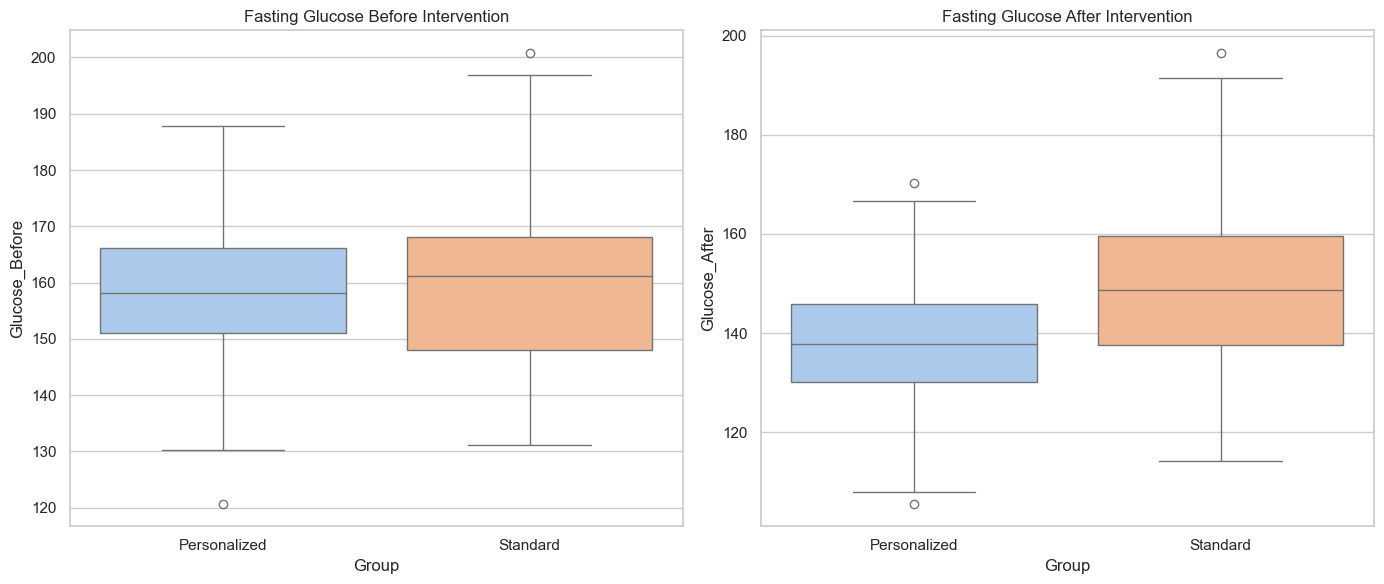

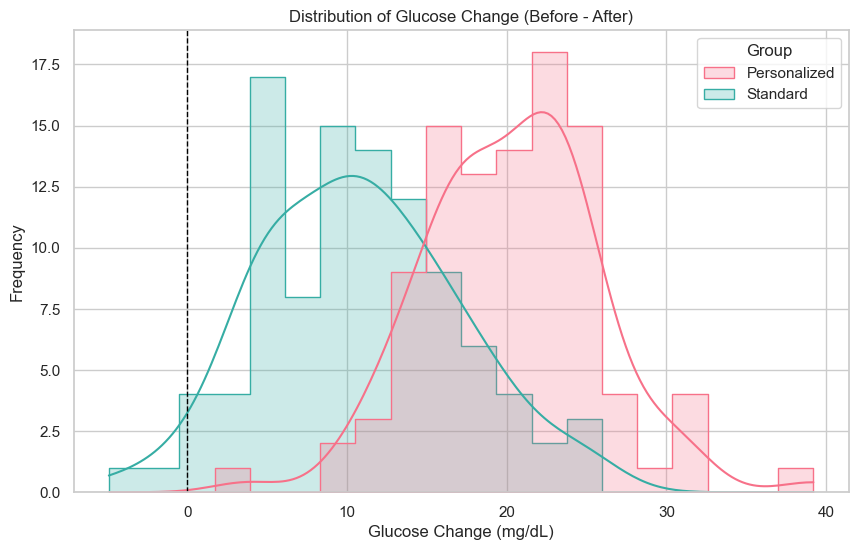

C:\Users\jshre\AppData\Local\Temp\ipykernel_19384\4103126020.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Group', y='mean', data=group_stats, palette='Set2')


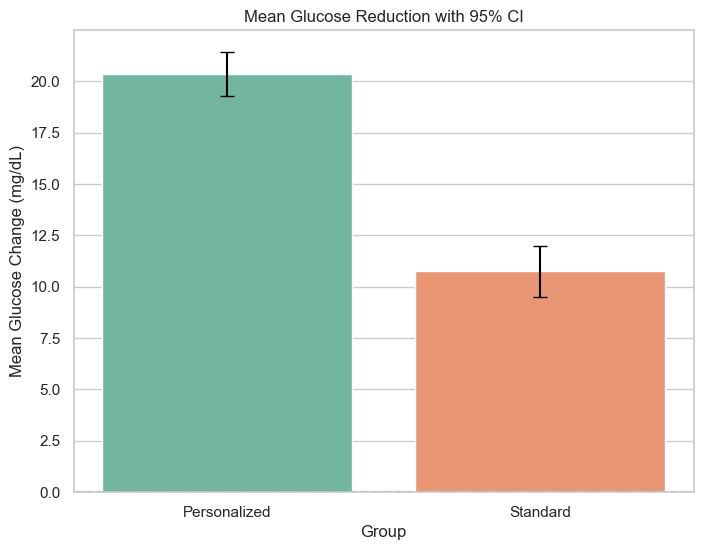

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# Set plot style
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# --- Boxplots: Glucose Before and After by Group ---
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.boxplot(x='Group', y='Glucose_Before', data=df_clean, palette='pastel')
plt.title("Fasting Glucose Before Intervention")

plt.subplot(1, 2, 2)
sns.boxplot(x='Group', y='Glucose_After', data=df_clean, palette='pastel')
plt.title("Fasting Glucose After Intervention")

plt.tight_layout()
plt.show()

# --- Histogram + KDE: Glucose Change by Group ---
plt.figure(figsize=(10, 6))
sns.histplot(data=df_clean, x='Glucose_Change', hue='Group', kde=True, bins=20, palette='husl', element='step')
plt.title("Distribution of Glucose Change (Before - After)")
plt.xlabel("Glucose Change (mg/dL)")
plt.ylabel("Frequency")
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.show()

# --- Bar Plot: Mean Glucose Change with 95% CI ---
group_stats = df_clean.groupby("Group")["Glucose_Change"].agg(['mean', 'count', 'std']).reset_index()
group_stats['sem'] = group_stats['std'] / np.sqrt(group_stats['count'])
group_stats['ci95'] = group_stats['sem'] * stats.t.ppf((1 + 0.95) / 2, group_stats['count'] - 1)

# Plot bar chart with error bars
plt.figure(figsize=(8, 6))
ax = sns.barplot(x='Group', y='mean', data=group_stats, palette='Set2')

# Add error bars manually
plt.errorbar(
    x=np.arange(len(group_stats)),
    y=group_stats['mean'],
    yerr=group_stats['ci95'],
    fmt='none',
    c='black',
    capsize=5
)


plt.title("Mean Glucose Reduction with 95% CI")
plt.ylabel("Mean Glucose Change (mg/dL)")
plt.xlabel("Group")
plt.axhline(0, color='gray', linestyle='--')
plt.show()


## Results

In [35]:
# Get earlier results again
mean1, lower1, upper1 = confidence_interval(group1)
mean2, lower2, upper2 = confidence_interval(group2)
mean_diff = mean1 - mean2
lower_diff = mean_diff - (mean1 - lower1 + upper2 - mean2) / 2  # approximate CI width
upper_diff = mean_diff + (mean1 - lower1 + upper2 - mean2) / 2

# Cohen's d
pooled_std = np.sqrt(((len(group1) - 1) * group1.std()**2 + (len(group2) - 1) * group2.std()**2) / (len(group1) + len(group2) - 2))
cohen_d = (mean1 - mean2) / pooled_std
effect_strength = (
    "Small" if abs(cohen_d) < 0.2 else
    "Medium" if abs(cohen_d) < 0.8 else
    "Large"
)

# p-value from independent t-test
stat, p_value = stats.ttest_ind(group1, group2, equal_var=False)

# Print conclusion summary
print("\n📋 Final Summary & Insights:\n")

print("🔹 Both groups (Personalized and Standard) showed significant glucose reduction individually (from paired t-tests).")
print("🔹 The Personalized group had a greater average reduction than the Standard group.")
print(f"   - Personalized: {mean1:.2f} mg/dL [95% CI: {lower1:.2f}, {upper1:.2f}]")
print(f"   - Standard:     {mean2:.2f} mg/dL [95% CI: {lower2:.2f}, {upper2:.2f}]")
print()

print(f"🔍 Difference in Mean Reduction: {mean_diff:.2f} mg/dL")
print(f"    95% CI: [{lower_diff:.2f}, {upper_diff:.2f}]")
print(f"    p-value: {p_value:.4f} → {'Statistically significant ✅' if p_value < 0.05 else 'Not statistically significant ❌'}")
print()

print(f"📏 Effect Size (Cohen’s d): {cohen_d:.2f} → {effect_strength} effect")

print("\n📌 Conclusion:")
if p_value < 0.05:
    print("✅ Personalized diet plans significantly reduce fasting glucose more than standard plans.")
    print("🔧 This supports evidence-based personalization in chronic disease dietary management.")
else:
    print("⚠️ No statistically significant difference found between groups.")
    print("🔍 Further investigation with a larger sample or better dietary adherence monitoring is recommended.")



📋 Final Summary & Insights:

🔹 Both groups (Personalized and Standard) showed significant glucose reduction individually (from paired t-tests).
🔹 The Personalized group had a greater average reduction than the Standard group.
   - Personalized: 20.33 mg/dL [95% CI: 19.26, 21.41]
   - Standard:     10.75 mg/dL [95% CI: 9.52, 11.98]

🔍 Difference in Mean Reduction: 9.58 mg/dL
    95% CI: [8.43, 10.73]
    p-value: 0.0000 → Statistically significant ✅

📏 Effect Size (Cohen’s d): 1.65 → Large effect

📌 Conclusion:
✅ Personalized diet plans significantly reduce fasting glucose more than standard plans.
🔧 This supports evidence-based personalization in chronic disease dietary management.
